## Model Traning

### 1.1 Impact Data and Required Packages

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# libraries for modeling
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [4]:
# Import the CSV Dataset as pandas DataFrame
df = pd.read_csv('data/StudentsPerformance.csv')
# Show the first 5 rows of the DataFrame
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# Preparing X and Y Variables
X = df.drop(columns=['math_score'])
X.head()
# print(type(X))

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
y = df['math_score']
y.head()
print(type(y))

<class 'pandas.Series'>


In [7]:
# Create Column Transformer with 3 types of Transformers
num_features = X.select_dtypes(exclude='string').columns
cat_features = X.select_dtypes(include='string').columns

In [8]:
# Check exact column names
print(df.columns.tolist())

# Check for hidden spaces
print([col for col in df.columns])

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transform = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transform, num_features)
    ]
)

In [10]:
X = preprocessor.fit_transform(X)
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [11]:
X.shape

(1000, 19)

In [12]:
# Separate dataset into train and test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to Give all Metrics After Model Training

In [13]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [15]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(verbose=False),
    "AdaBoost Regressor" : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train Model

    # Make Prediction 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluste Train and Test Dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    # print(model_list)

    print("Model Performance for Traning Set :")
    print(f"- Mean Absolute Error : {model_train_mae:.4f} ")
    print(f"- Mean Square Error : {model_train_mse:.4f} ")
    print(f"- Root Mean Square Error : {model_train_rmse:.4f} ")
    print(f"- R2 Score : {model_train_r2:.4f} ")

    print("-"*35)

    print("Model Performance for Testing Set :")
    print(f"- Mean Absolute Error : {model_test_mae:.4f} ")
    print(f"- Mean Square Error : {model_test_mse:.4f} ")
    print(f"- Root Mean Square Error : {model_test_rmse:.4f} ")
    print(f"- R2 Score : {model_test_r2:.4f} ")
    r2_list.append(model_test_r2)    

    print('='*35)
    print('\n')


Linear Regression
Model Performance for Traning Set :
- Mean Absolute Error : 4.2667 
- Mean Square Error : 28.3349 
- Root Mean Square Error : 5.3231 
- R2 Score : 0.8743 
-----------------------------------
Model Performance for Testing Set :
- Mean Absolute Error : 4.2148 
- Mean Square Error : 29.0952 
- Root Mean Square Error : 5.3940 
- R2 Score : 0.8804 


Lasso
Model Performance for Traning Set :
- Mean Absolute Error : 5.2063 
- Mean Square Error : 43.4784 
- Root Mean Square Error : 6.5938 
- R2 Score : 0.8071 
-----------------------------------
Model Performance for Testing Set :
- Mean Absolute Error : 5.1579 
- Mean Square Error : 42.5064 
- Root Mean Square Error : 6.5197 
- R2 Score : 0.8253 


Ridge
Model Performance for Traning Set :
- Mean Absolute Error : 4.2650 
- Mean Square Error : 28.3378 
- Root Mean Square Error : 5.3233 
- R2 Score : 0.8743 
-----------------------------------
Model Performance for Testing Set :
- Mean Absolute Error : 4.2111 
- Mean Square E

### Results

In [16]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.853224
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.847240
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.760498


## Linear Regression

In [17]:
linear_model = LinearRegression(fit_intercept=True)
linear_model = linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accyracy of the model is %.2f" %score)

Accyracy of the model is 88.04


### Plot y_pred and Y_test

Text(0, 0.5, 'Predicted')

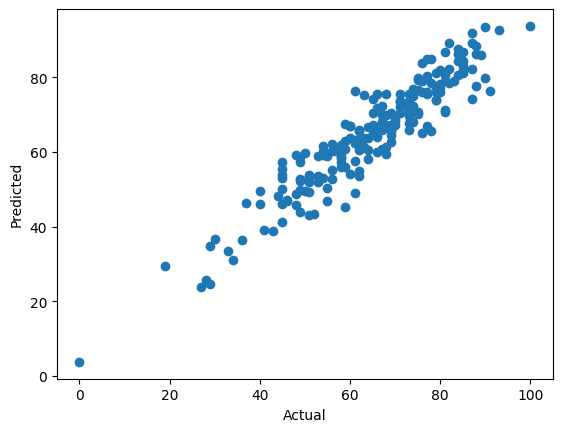

In [18]:
plt.scatter(y_test, y_pred)
# plt.plot(linear_model.predict(y_test))
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

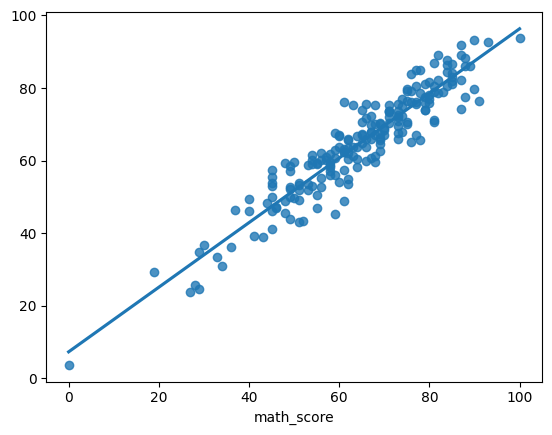

In [19]:
sns.regplot(x=y_test, y=y_pred, ci=None)

### Difference between actual and predicted values

In [20]:
pred_df = pd.DataFrame({'Actual Value':y_test, 'Predicted Value': y_pred, 'Difference': y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
